In [90]:
import pandas as pd
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima_process import ArmaProcess
import os
import warnings
warnings.filterwarnings("ignore")
os.chdir("/Users/mike_/OneDrive/Escritorio")
df = pd.read_csv("TempNY.csv")
df = df.drop("Unnamed: 2", axis = 1)
df.index = df["Year"]
df = df.drop("Year", axis = 1)
df


,Average
Year,
1870,53.60
1871,51.13
1872,50.98
1873,50.98
1874,51.34
...,...
2016,57.18
2017,56.22
2018,55.88


In [91]:
# Definir grupo de prueba y entrenamiento
len_train = int(len(df) * 0.9)
len_test = int(len(df) * 0.1)
train = df[0:len_train]
test = df[len_train:]


In [92]:
test

,Average
Year,
2005,55.72
2006,56.79
2007,55.01
2008,55.32
2009,54.02
2010,56.69
2011,56.41
2012,57.31
2013,55.32


In [93]:
train

,Average
Year,
1870,53.60
1871,51.13
1872,50.98
1873,50.98
1874,51.34
...,...
2000,53.84
2001,56.25
2002,56.39


In [94]:
# Prueba es estacionariedad de Dicky-Fuller 
# H0  la seri es no estacionario ( la media va cmambiando a lo largo del tiempo)
# HA : la serie si es estacionaria (la media si va cambiando a lo largo del tiempo)

from statsmodels.tsa.stattools import  adfuller
result = adfuller(train["Average"])
print("El valor p de la prueba de DICKEY-FULLER es ", result[1])


El valor p de la prueba de DICKEY-FULLER es  0.42201206191180785


In [95]:
# Conclusion...no hay evidencia estadistica papra rechazar H0 y por lo tanto decir que la serie  NO ES ESTACIONARIA

In [96]:
# Hay que transformarla a una serie que si sea esacioanria.. la mas comun es sacar diferencia entre los datos y
#Generamos una nueva base de datos de esas diferencias

# Aplicar primeras diferencias paa buscar convertir la serie es una serie stacionaria

train["temp_change"] = train["Average"].diff()
train = train.dropna()
train

,Average,temp_change
Year,,
1871,51.13,-2.47
1872,50.98,-0.15
1873,50.98,0.00
1874,51.34,0.36
1875,49.43,-1.91
...,...,...
2000,53.84,-2.64
2001,56.25,2.41
2002,56.39,0.14


In [97]:
# Dickey-fuller sobre las diferencias

result2 = adfuller(train["temp_change"])
print("El valor p de la prueba de DICKEY-FULLER es ", result2[1])



El valor p de la prueba de DICKEY-FULLER es  1.5713108896118464e-13


In [98]:
#La serie YA ES ESTACIONARIA.. solo se aplico 1 diferencia

<Axes: xlabel='Year'>

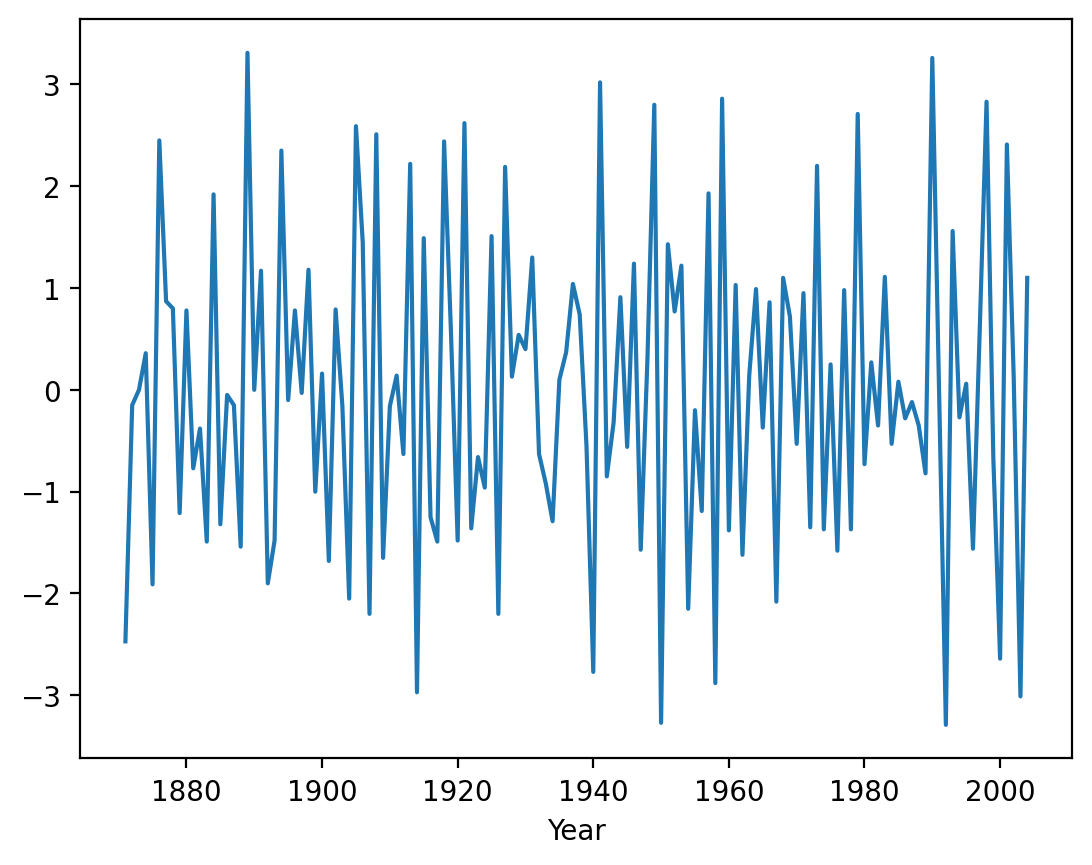

In [99]:
train["temp_change"].plot()

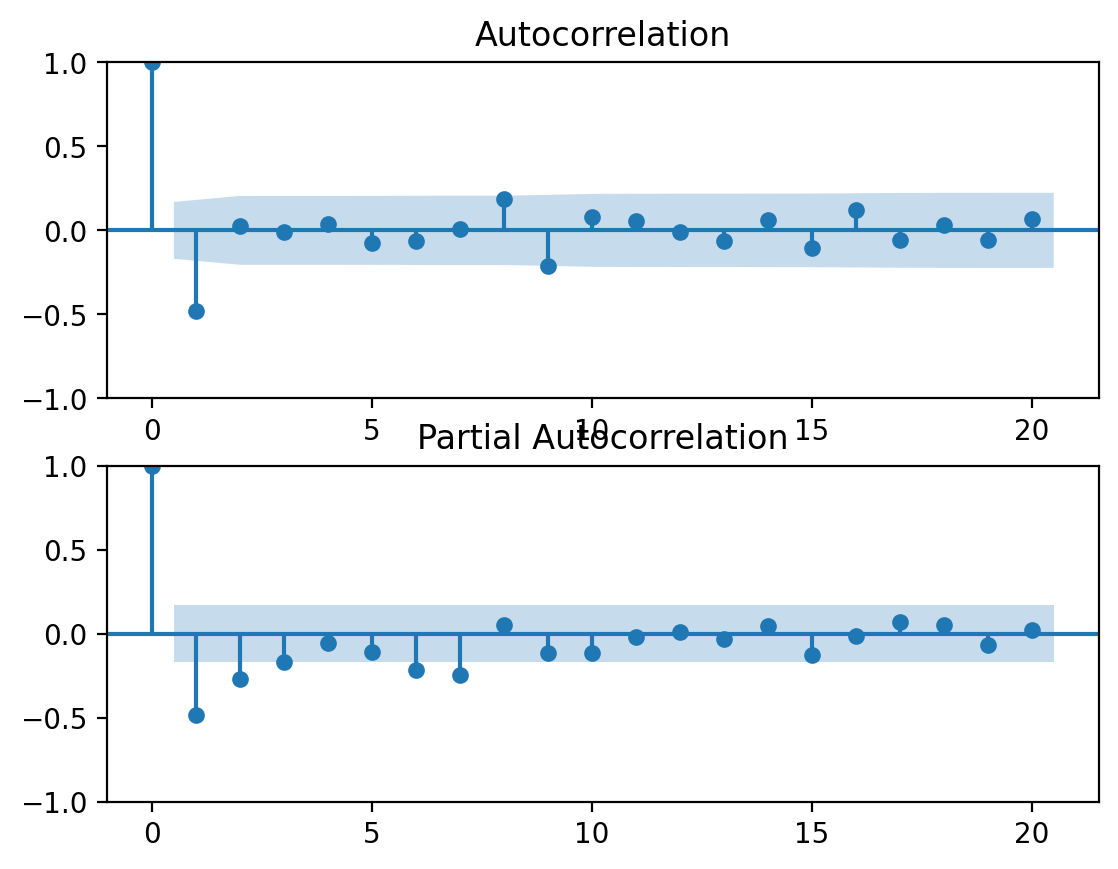

In [100]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(2,1)

# Grafica de la función de autocorrelación ACF
plot_acf(train["temp_change"], lags=20, ax = axes[0], alpha = 0.05)

# Graficación de la funcion de autocorrelación parcial PACF
plot_pacf(train["temp_change"], lags=20, ax = axes[1], alpha = 0.05)

plt.show()


In [101]:
import itertools
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

p = range(0, 4)
d = [1]
q = range(0, 4)

combinations = list(itertools.product(p, d, q))

results = []

for order in combinations:
    try:
        model = ARIMA(train["Average"], order=order)
        fitted = model.fit()
        results.append((order, fitted.aic))
    except:
        continue

results_df = pd.DataFrame(results, columns=["(p,d,q)", "AIC"])
results_df = results_df.sort_values("AIC")

results_df.head(10)

,"(p,d,q)",AIC
1,"(0, 1, 1)",428.324117
5,"(1, 1, 1)",429.955521
2,"(0, 1, 2)",429.999440
9,"(2, 1, 1)",431.526948
3,"(0, 1, 3)",431.564546
11,"(2, 1, 3)",431.714086
6,"(1, 1, 2)",431.735162
7,"(1, 1, 3)",433.473260
13,"(3, 1, 1)",433.511842
10,"(2, 1, 2)",433.643168


In [102]:
# Parametros optimos.... (0,1,1) 428.32

In [103]:
df = pd.read_csv("TempNY.csv")
df = df.drop("Unnamed: 2", axis = 1)
df.index = df["Year"]

len_train = int(len(df) * 0.9)
len_test = int(len(df) * 0.1)
train = df[0:len_train]
test = df[len_train:]

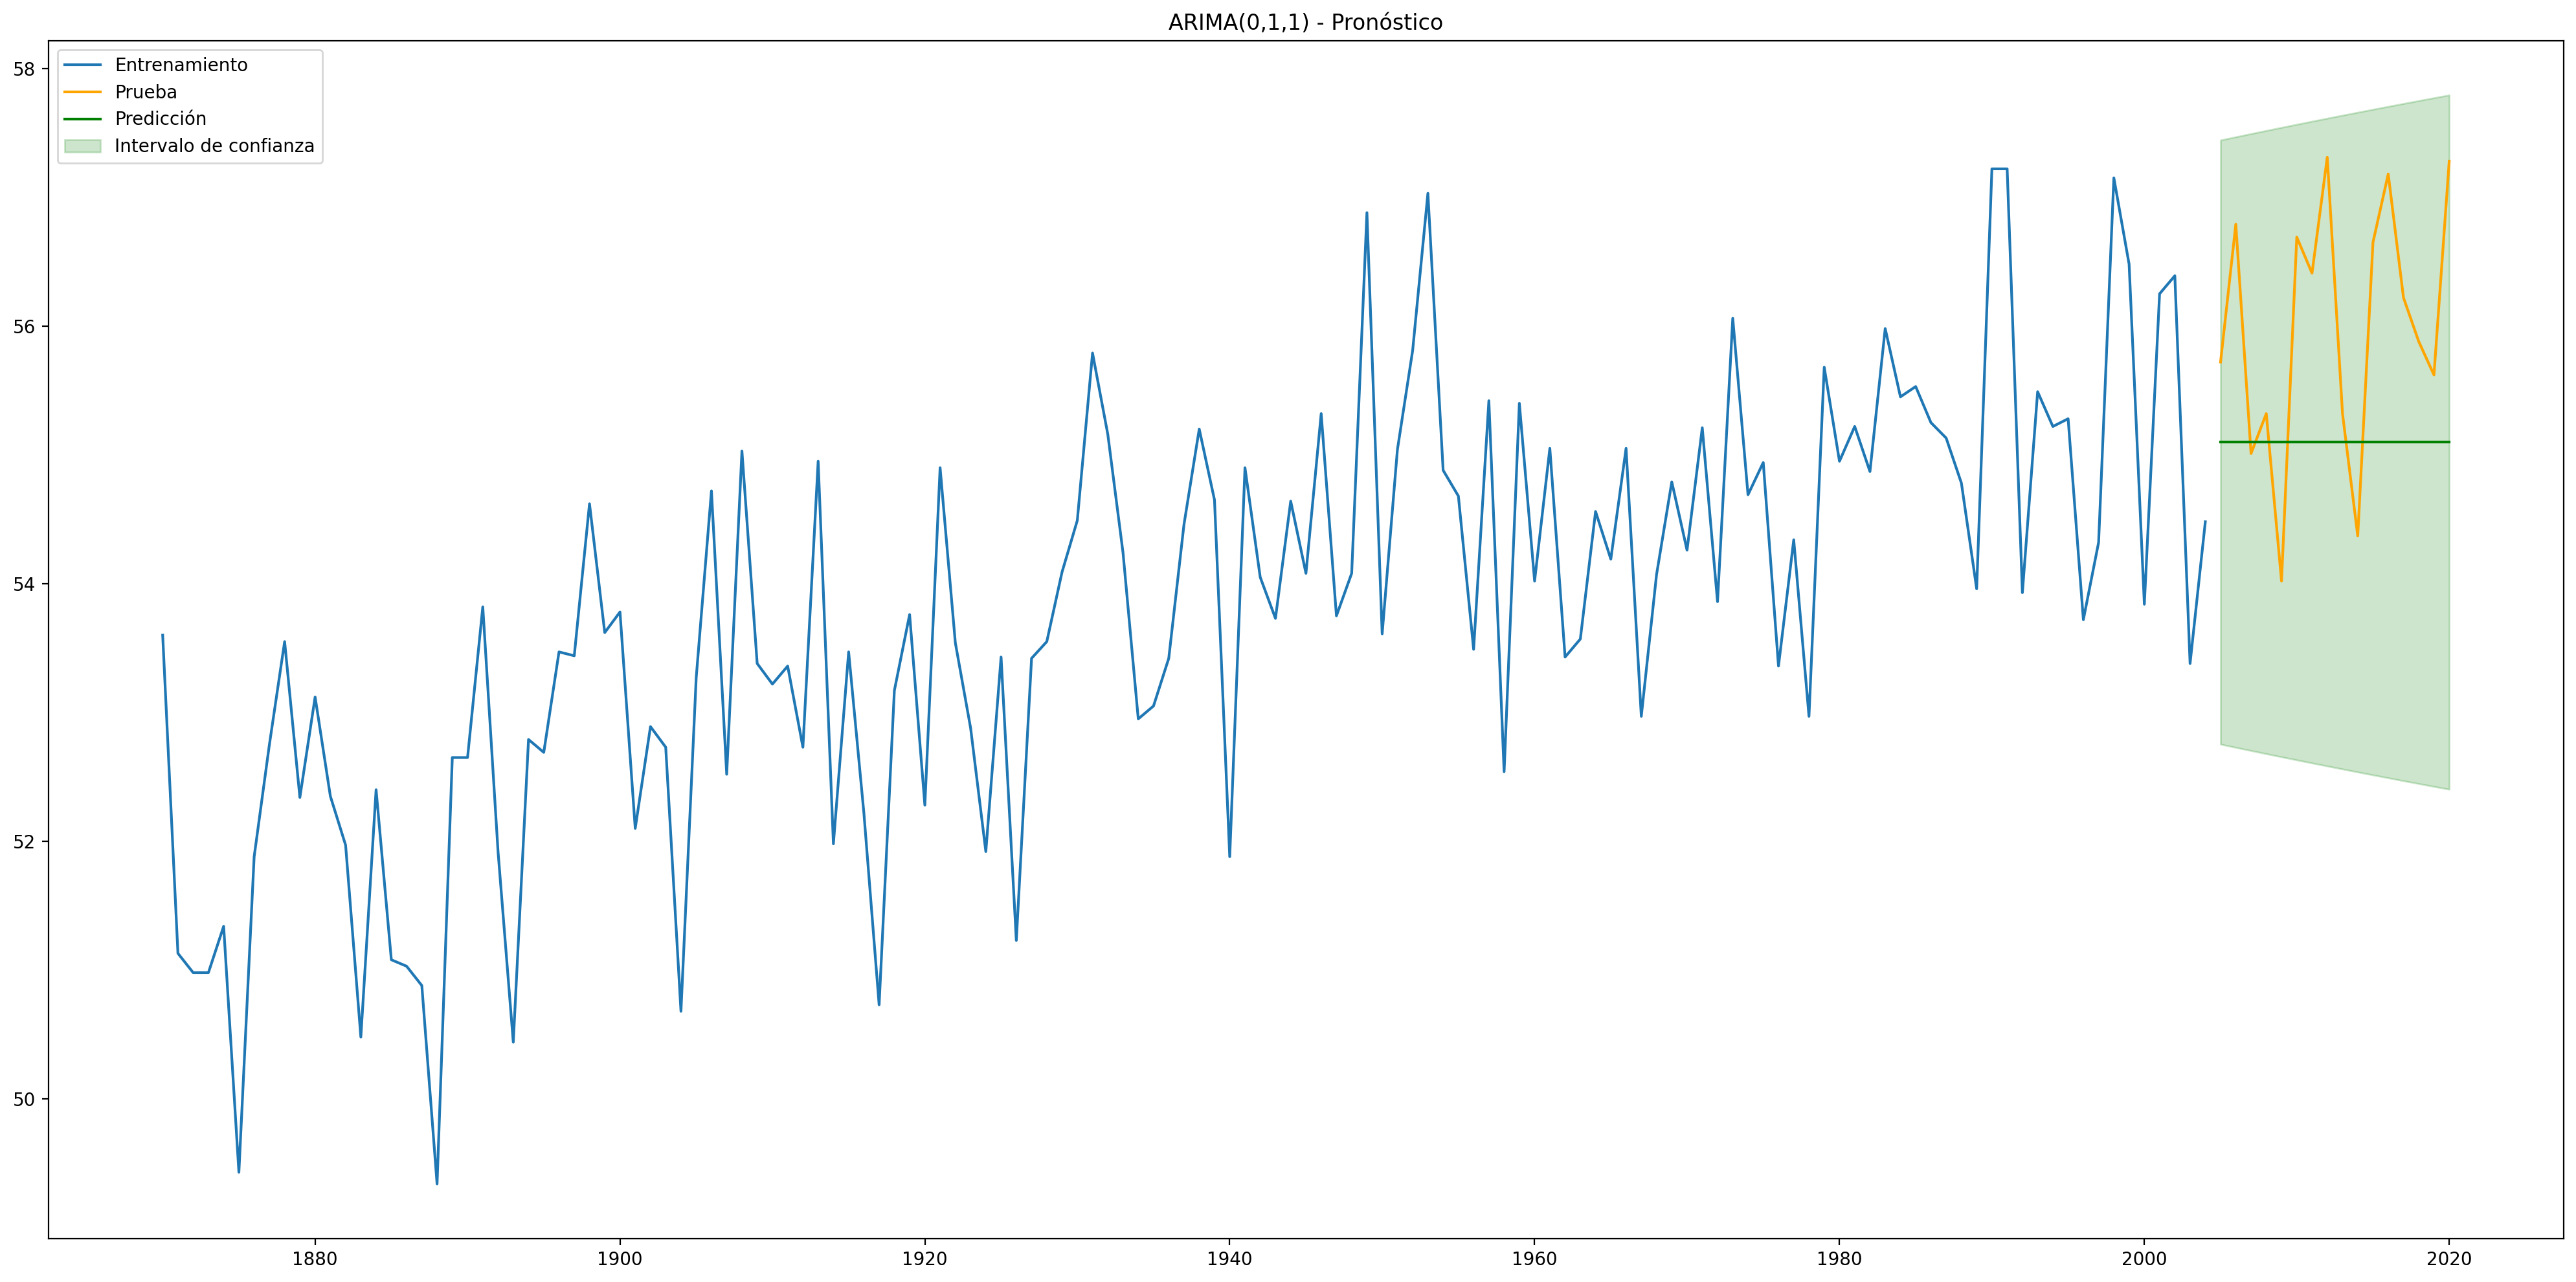

<Figure size 640x480 with 0 Axes>

In [112]:
from statsmodels.tsa.arima.model import ARIMA

# Ajustar el modelo final
final_model = ARIMA(train["Average"], order=(0,1,1)).fit()

#Hacer predicción para el tamaño del test
forecast = final_model.get_forecast(steps=len(test))

forecast_mean = forecast.predicted_mean #predcciones
forecast_ci = forecast.conf_int()

#Graficar todo junto

plt.figure(figsize=(20,10))

# Train
plt.plot(train.index, train["Average"], label="Entrenamiento")

# Test
plt.plot(test.index, test["Average"], label="Prueba", color="orange")

# Predicción puntual
plt.plot(test.index, forecast_mean, label="Predicción", color="green")

# Intervalos de confianza
plt.fill_between(test.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 color="green",
                 alpha=0.2,
                 label="Intervalo de confianza")

plt.legend()
plt.title("ARIMA(0,1,1) - Pronóstico")
plt.tight_layout()
plt.show()
plt.savefig("pronostico_arima.png", dpi=300, bbox_inches='tight')

In [105]:
#El modelo ARIMA(0,1,1) genera pronósticos consistentes con un comportamiento tipo random walk. Las observaciones del conjunto de prueba permanecen
#dentro del intervalo de confianza del 95%, lo que sugiere un ajuste razonable. Sin embargo, el modelo tiende a producir pronósticos casi constantes, 
#lo cual es característico de este tipo de especificación.

In [106]:
train

,Year,Average
Year,,
1870,1870,53.60
1871,1871,51.13
1872,1872,50.98
1873,1873,50.98
1874,1874,51.34
...,...,...
2000,2000,53.84
2001,2001,56.25
2002,2002,56.39


In [107]:
test

,Year,Average
Year,,
2005,2005,55.72
2006,2006,56.79
2007,2007,55.01
2008,2008,55.32
2009,2009,54.02
2010,2010,56.69
2011,2011,56.41
2012,2012,57.31
2013,2013,55.32


In [108]:
forecast_mean

135    55.098228
136    55.098228
137    55.098228
138    55.098228
139    55.098228
140    55.098228
141    55.098228
142    55.098228
143    55.098228
144    55.098228
145    55.098228
146    55.098228
147    55.098228
148    55.098228
149    55.098228
150    55.098228
Name: predicted_mean, dtype: float64

In [109]:
forecast_mean.index = test.index
forecast_ci.index = test.index

In [110]:
real = test["Average"]
pred = forecast_mean

mse = np.mean((real - pred) ** 2)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((real - pred) / real)) * 100

print("MSE =", round(mse, 4))
print("RMSE =", round(rmse, 4))
print("MAPE =", round(mape, 2), "%")

MSE = 1.7399
RMSE = 1.319
MAPE = 1.99 %


In [84]:
#Aunque la predicción puntual es relativamente plana y no reproduce exactamente las fluctuaciones anuales del conjunto de prueba, 
#los indicadores de error muestran un desempeño adecuado. El MAPE de 1.99% indica que el error porcentual promedio es bajo, y el RMSE es 
#pequeño en relación con el nivel de la serie. Por lo tanto, el modelo puede considerarse confiable para estimar el nivel general de la serie, 
#aunque presenta limitaciones para capturar variaciones específicas de corto plazo.